## Step 1 — Project Introduction

### Can We Predict Who Survived the Titanic Disaster?

The Titanic dataset contains information about passengers who were aboard the RMS Titanic.

The main objective of this project is to investigate whether passenger characteristics can be used to predict survival.

Instead of starting immediately with machine learning, we will first explore the data and allow the data to guide our questions.

The main question of this project is:

> **Can we predict whether a Titanic passenger survived based on the information available about that passenger?**

To answer this question, the project will follow a complete machine learning workflow based on the concepts learned during Days 1–5.

The workflow will include:

1. Understanding the dataset.
2. Exploring the passengers and their survival outcomes.
3. Asking data-driven questions.
4. Visualizing important relationships.
5. Identifying useful features.
6. Cleaning and engineering features.
7. Splitting the data into training and test sets.
8. Using cross-validation.
9. Comparing machine learning models.
10. Building a preprocessing and modeling Pipeline.
11. Using a ColumnTransformer for mixed data.
12. Tuning the complete Pipeline with GridSearchCV.
13. Evaluating the final model on unseen test data.
14. Comparing the final model against a simple baseline.
15. Interpreting the final results.

The goal is not only to obtain a good predictive score.

The goal is to build a model that is:

* reliable,
* reproducible,
* interpretable,
* properly evaluated,
* and protected against data leakage.

<hr style="height: 5px; background-color: #2e8b57; border: none;">


## Step 2 — Import Libraries

In [245]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

### Explanation

These libraries provide everything required for the project.

`pandas` will be used to inspect and manipulate the Titanic dataset.

`numpy` will support numerical operations.

`matplotlib` will be used to create charts that help us investigate relationships in the data.

`Scikit-learn` provides the machine learning tools.

The most important tools for the final workflow are:

| Tool                     | Purpose                                       |
| ------------------------ | --------------------------------------------- |
| `train_test_split`       | Separate training and test data               |
| `StratifiedKFold`        | Perform stratified cross-validation           |
| `cross_val_score`        | Evaluate model stability                      |
| `GridSearchCV`           | Tune hyperparameters                          |
| `ColumnTransformer`      | Preprocess different column types differently |
| `Pipeline`               | Combine preprocessing and modeling            |
| `StandardScaler`         | Scale numerical features                      |
| `OneHotEncoder`          | Encode categorical features                   |
| `RandomForestClassifier` | Tree-based classification model               |
| `SVC`                    | Support Vector Machine                        |
| Classification metrics   | Evaluate predictions                          |

At this stage, we have only prepared the tools.

We have not yet made any decisions about which features should be used. Those decisions will come from exploring the dataset.

<hr style="height: 5px; background-color: #2e8b57; border: none;">

## Step 3 — Load the Titanic Dataset

In [246]:
df = pd.read_csv("titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,\N,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,\N,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,\N,S


### Explanation
The first question is simple:
> **Did the Titanic dataset load correctly, and what do the passenger records look like?**
The `head()` function displays the first five passengers.
Each row represents one passenger, while each column contains information about that passenger.

From the first rows, we can already identify variables such as:

* survival status,
* passenger class,
* sex,
* age,
* number of siblings or spouses,
* number of parents or children,
* ticket information,
* fare,
* cabin,
* and port of embarkation.

However, looking at only five rows is not enough to understand the dataset.

Therefore, the next step is to investigate its complete structure.

<hr style="height: 5px; background-color: #2e8b57; border: none;">

## Step 4 — Understand the Dataset Structure

In [247]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape:
(891, 12)

Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age                str
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Missing Values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

Duplicate Rows:
0


## Explanation

Now we ask:

> **What is the structure and quality of the Titanic dataset?**

The dataset contains **891 passengers and 12 columns**.

The columns include both numerical and categorical information.

This distinction will become important later because numerical and categorical features should not necessarily receive the same preprocessing.

### Numerical Information

Examples include:

* `PassengerId`
* `Survived`
* `Pclass`
* `SibSp`
* `Parch`
* `Fare`

### Categorical Information

Examples include:

* `Sex`
* `Name`
* `Ticket`
* `Cabin`
* `Embarked`

There is also an important issue in the dataset:

`Age` is stored as an `object` rather than a numerical data type.

This means we should not blindly assume that it can immediately be treated as a numerical feature.

The dataset also represents missing cabin information using `\N`, so this needs to be handled explicitly.

These observations will guide our cleaning process later.

The important principle is:

> **We inspect the data first and make preprocessing decisions based on what we actually find.**

<hr style="height: 5px; background-color: #2e8b57; border: none;">

## Step 5 — Understand the Target Variable


In [248]:
print("Survival Counts:")
print(df["Survived"].value_counts())

print("\nSurvival Percentages:")
print(
    df["Survived"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Survival Counts:
Survived
0    549
1    342
Name: count, dtype: int64

Survival Percentages:
Survived
0    61.62
1    38.38
Name: proportion, dtype: float64


### Explanation

Now we reach the central variable of the project:

`Survived`

The target has two possible values:

| Value | Meaning         |
| ----: | --------------- |
|     0 | Did not survive |
|     1 | Survived        |

The question we are asking is:

> **Was survival evenly distributed among the passengers?**

The `value_counts()` result gives us the number of passengers in each class.

The percentage calculation makes the comparison easier because it expresses the result relative to the total number of passengers.

This is important for the machine learning stage.

If one outcome is substantially more common than the other, a model could obtain a reasonable accuracy simply by favoring the majority class.

Therefore, we will later compare our machine learning models against a simple baseline and use more than accuracy to judge their performance.

<hr style="height: 5px; background-color: #2e8b57; border: none;">

## Step 6 — Visualize Survival Distribution

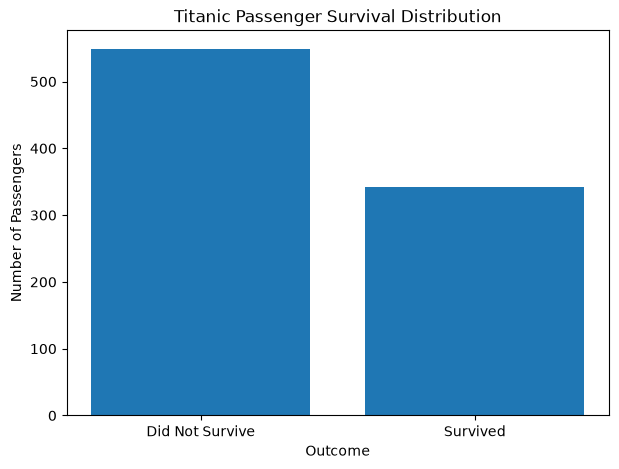

In [249]:
survival_counts = df["Survived"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Did Not Survive", "Survived"],
    survival_counts.values
)

plt.xlabel("Outcome")
plt.ylabel("Number of Passengers")
plt.title("Titanic Passenger Survival Distribution")

plt.show()


### Interpretation

This chart gives us the first visual answer to our question:

> **What was the overall survival pattern among Titanic passengers?**

The two bars represent the two possible outcomes.

The height of each bar represents the number of passengers belonging to that outcome.

If the `Did Not Survive` bar is higher, then the dataset contains more passengers who did not survive than passengers who survived.

This gives us an important baseline understanding of the problem before we investigate individual passenger characteristics.

However, this chart also raises a more interesting question:

> **If survival was not the same for everyone, what passenger characteristics were associated with survival?**

This leads us to the next stage of the analysis.

We will investigate variables such as **sex, passenger class, age, fare, and family relationships** to see whether the data reveals meaningful differences between survivors and non-survivors.

<hr style="height: 5px; background-color: #2e8b57; border: none;">


## Step 7 — Visualize Survival by Passenger Class

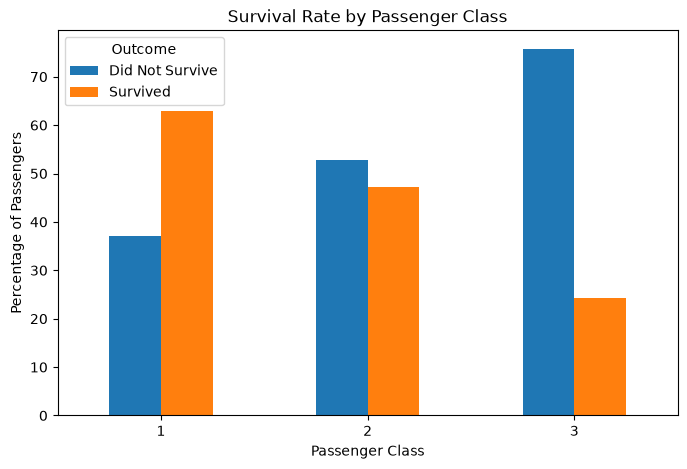

In [250]:
pclass_plot = pd.crosstab(
    df["Pclass"],
    df["Survived"],
    normalize="index"
) * 100

pclass_plot.columns = [
    "Did Not Survive",
    "Survived"
]

pclass_plot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Passenger Class")
plt.ylabel("Percentage of Passengers")
plt.title("Survival Rate by Passenger Class")
plt.xticks(rotation=0)
plt.legend(title="Outcome")

plt.show()

### Interpretation

**Question**
>Was passenger class associated with survival?

The chart shows that survival rates differ across passenger classes.

First-class passengers have a substantially higher survival proportion than third-class passengers.

This means `Pclass` is another informative predictor.

The result also suggests that passenger socioeconomic position may have been associated with access to safer locations and evacuation opportunities.

For the machine learning model, this gives us another strong reason to retain `Pclass`.

We now have two variables that appear particularly informative:

- `Sex`
- `Pclass`

However, we should continue investigating numerical characteristics rather than stopping after the first strong relationships.

<hr style="height: 5px; background-color: #2e8b57; border: none;">

## Step 8 — Convert Age to Numeric

In [251]:
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

print(df["Age"].dtype)

print("\nMissing Age Values:")
print(df["Age"].isnull().sum())

float64

Missing Age Values:
177


### Explanation

We previously discovered that `Age` was stored as an `object`.

This is not appropriate for numerical modeling.

We therefore convert it into a numerical variable.

Values that cannot be converted are replaced with `NaN`.

This is important because later the preprocessing pipeline will treat `Age` as a numerical feature and scale it appropriately.

The missing age values will not simply be replaced using information from the entire dataset.

Instead, missing-value treatment will be performed inside the pipeline so that the imputation process is learned only from the training data during cross-validation.

This is another important protection against data leakage.

<hr style="height: 5px; background-color: #2e8b57; border: none;">

## Step 9 — Question 3: Was Age Related to Survival?

In [252]:
age_survival = df.groupby("Survived")["Age"].agg(
    ["count", "mean", "median", "min", "max"]
)

age_survival

,count,mean,median,min,max
Survived,,,,,
0,424,30.626179,28.0,1.00,74.0
1,290,28.343690,28.0,0.42,80.0


## Step 10 — Visualize Age Distribution by Survival

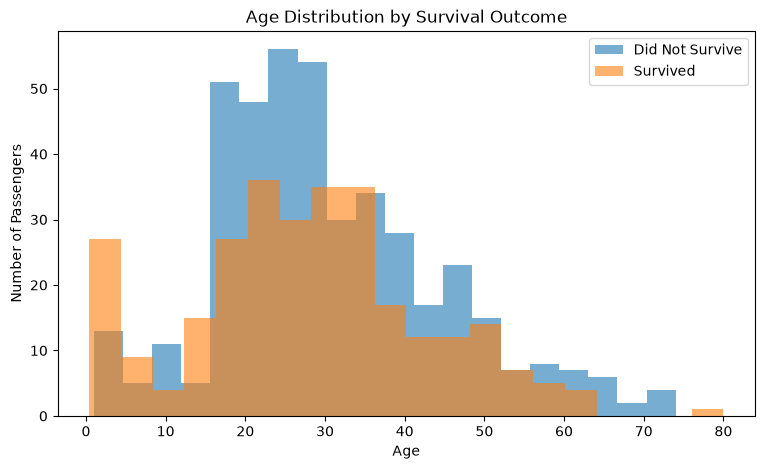

In [253]:
plt.figure(figsize=(9, 5))

plt.hist(
    df.loc[df["Survived"] == 0, "Age"].dropna(),
    bins=20,
    alpha=0.6,
    label="Did Not Survive"
)

plt.hist(
    df.loc[df["Survived"] == 1, "Age"].dropna(),
    bins=20,
    alpha=0.6,
    label="Survived"
)

plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.title("Age Distribution by Survival Outcome")
plt.legend()

plt.show()

### Interpretation

**Question**
>Do the age distributions of survivors and non-survivors look different?

The two distributions overlap substantially, meaning age alone does not perfectly separate survivors from non-survivors.

However, the distributions are not identical.

This suggests that `Age` may provide useful information when combined with other variables such as sex and passenger class.

This is exactly why machine learning can be useful here.

A single feature may not be sufficient, but several features together can provide a stronger prediction.

We therefore keep `Age` as a numerical predictor and later handle its missing values inside the preprocessing pipeline.

<hr style="height: 5px; background-color: #2e8b57; border: none; separator: false;">

## Step 11 — Question 5: Did Family Size Matter?

In [254]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

family_survival = df.groupby("FamilySize")["Survived"].agg(
    ["count", "mean"]
)

family_survival["mean"] = family_survival["mean"] * 100

family_survival.round(2)

,count,mean
FamilySize,,
1,537,30.35
2,161,55.28
3,102,57.84
4,29,72.41
5,15,20.00
6,22,13.64
7,12,33.33
8,6,0.00
11,7,0.00


### Explanation

The dataset contains two separate family-related variables:

- `SibSp`: siblings and spouses
- `Parch`: parents and children

A more intuitive feature is total family size.

We define:
`FamilySize = SibSp + Parch + 1`

The `+1` represents the passenger themselves.

For example, a passenger with:

1 sibling
2 parents/children

would have:
`1 + 2 + 1 = 4`
family members in the group.

The question is:
>Was survival related to family size?

We calculate survival rates for different family sizes.

<hr style="height: 5px; background-color: #2e8b57; border: none; separator: false;">

## Step 12 — Visualize Family Size and Survival

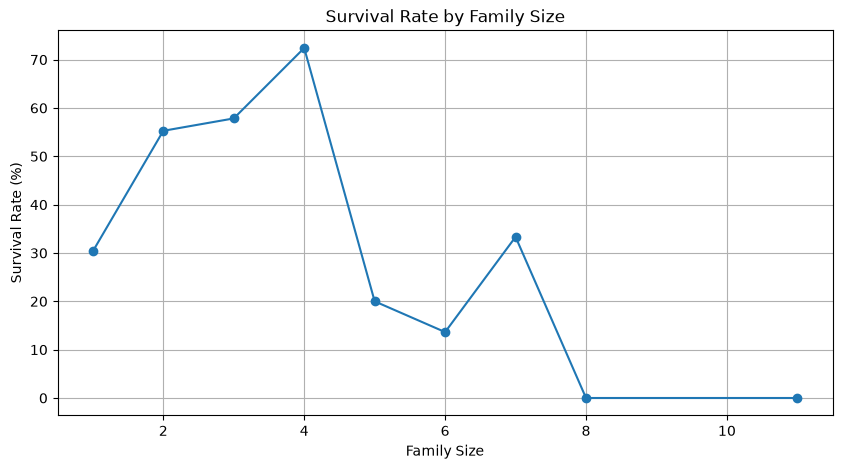

In [255]:
family_plot = (
    df.groupby("FamilySize")["Survived"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(10, 5))

plt.plot(
    family_plot.index,
    family_plot.values,
    marker="o"
)

plt.xlabel("Family Size")
plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate by Family Size")

plt.grid(True)
plt.show()

### Interpretation

**Question**
>Does family size show a meaningful survival pattern?

The chart shows that survival rates vary across family sizes.

Very small families and larger families do not necessarily have the same survival probability.

The relationship is not simply a straight increase or decrease.

This is useful because it suggests that the effect of family relationships may be more complicated than simply having more relatives on board.

Instead of using only `SibSp` and `Parch`, the engineered `FamilySize` feature can summarize family structure in a more interpretable way.

We will retain this engineered feature for the machine learning stage.

<hr style="height: 5px; background-color: #2e8b57; border: none; separator: false;">

## Step 13 — Feature Engineering: Is the Passenger Alone?

In [256]:
df["IsAlone"] = (
    df["FamilySize"] == 1
).astype(int)

print(
    df[
        ["SibSp", "Parch", "FamilySize", "IsAlone"]
    ].head(10)
)

   SibSp  Parch  FamilySize  IsAlone
0      1      0           2        0
1      1      0           2        0
2      0      0           1        1
3      1      0           2        0
4      0      0           1        1
5      0      0           1        1
6      0      0           1        1
7      3      1           5        0
8      0      2           3        0
9      1      0           2        0


### Explanation

Family size gives us another useful question:
>Was traveling alone associated with survival?

We create `IsAlone`.

Value	Meaning
0	Passenger traveled with at least one family member
1	Passenger traveled alone

This converts family structure into a simple binary feature.

It can capture information that may not be obvious when looking at `SibSp` and `Parch` separately.

This feature is created directly from the passenger's own row and does not use the target variable, so it does not introduce target leakage.

<hr style="height: 5px; background-color: #2e8b57; border: none; separator: false;">

## Step 14 — Feature Engineering: Extract Passenger Title

In [257]:
df["Title"] = (
    df["Name"]
    .str.extract(r",\s*([^.]*)\.", expand=False)
    .str.strip()
)

print(df["Title"].value_counts().head(15))

Title
Mr        517
Miss      182
Mrs       125
Master     40
Dr          7
Rev         6
Major       2
Mlle        2
Col         2
Don         1
Mme         1
Ms          1
Lady        1
Sir         1
Capt        1
Name: count, dtype: int64


### Explanation

Passenger names often contain social titles such as:

- Mr
- Mrs
- Miss
- Master
- Dr
- Rev

These titles may provide useful information about:

- Age
- Gender
- Social status

We extract the title from the passenger's name using a regular expression.

This creates a new feature that may help the model identify survival patterns that are not visible through age or gender alone.

<hr style="height: 5px; background-color: #2e8b57; border: none;">

## Step 15 — Simplify Passenger Titles

In [258]:
common_titles = [
    "Mr",
    "Miss",
    "Mrs",
    "Master"
]

df["Title"] = df["Title"].where(
    df["Title"].isin(common_titles),
    "Rare"
)

print(df["Title"].value_counts())

Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64


### Explanation

Some passenger titles appear only a few times in the dataset.

Keeping every unique title would create many unnecessary categories.

To reduce complexity:

- Common titles are kept as they are.
- Rare titles are grouped into a single category called `Rare`.

This helps the model focus on meaningful patterns while reducing noise.

<hr style="height: 5px; background-color: #2e8b57; border: none;">

## Step 16 — Feature Engineering: Cabin Information Availability

In [259]:
df["CabinKnown"] = df["Cabin"].notna().astype(int)

print(df["CabinKnown"].value_counts())

print(
    df.groupby("CabinKnown")["Survived"]
    .mean()
    .mul(100)
    .round(2)
)

CabinKnown
1    891
Name: count, dtype: int64
CabinKnown
1    38.38
Name: Survived, dtype: float64


### Explanation

Many passengers have missing cabin information.

Instead of using the cabin number directly, we create a simpler feature:

`CabinKnown`

| Value | Meaning |
|---------|---------|
| 0 | Cabin information is missing |
| 1 | Cabin information is available |

This allows us to investigate whether having recorded cabin information is associated with survival.

<hr style="height: 5px; background-color: #2e8b57; border: none;">

## Step 17 — Select Features for Machine Learning

In [260]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone",
    "Title",
    "CabinKnown"
]

x = df[features].copy()
y = df["Survived"].copy()

print("Selected Features:")
print(x.columns.tolist())

print("\nFeature Shape:")
print(x.shape)

Selected Features:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title', 'CabinKnown']

Feature Shape:
(891, 11)


### Explanation 
 
Before training a model, we select the features that will be used as predictors. 
 
These features include: 
 
- Demographic information 
- Ticket information 
- Family-related features 
- Engineered features created during analysis 
 
The target variable remains: 
 
`Survived` 
 
The selected feature matrix is stored in `x`, while the target is stored in `y`. 

<hr style="height: 5px; background-color: #2e8b57; border: none;">

## Step 18 — Check Data Quality Before Modeling

In [261]:
print("Missing Values:")
print(x.isnull().sum())

print("\nData Types:")
print(x.dtypes)

print("\nTarget Distribution:")
print(y.value_counts())

Missing Values:
Pclass          0
Sex             0
Age           177
SibSp           0
Parch           0
Fare            0
Embarked        0
FamilySize      0
IsAlone         0
Title           0
CabinKnown      0
dtype: int64

Data Types:
Pclass          int64
Sex               str
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked          str
FamilySize      int64
IsAlone         int64
Title             str
CabinKnown      int64
dtype: object

Target Distribution:
Survived
0    549
1    342
Name: count, dtype: int64


### Explanation 
 
Before building a machine learning model, we verify: 
 
- Missing values 
- Data types 
- Target distribution 
 
This helps ensure that the dataset is suitable for preprocessing and model training. 

<hr style="height: 5px; background-color: #2e8b57; border: none;">

## Step 19 — Split the Dataset into Training and Testing Sets

In [262]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", x_train.shape)
print("Test Set:", x_test.shape)

print("\nTraining Target Distribution:")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTest Target Distribution:")
print(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Training Set: (712, 11)
Test Set: (179, 11)

Training Target Distribution:
Survived
0    61.66
1    38.34
Name: proportion, dtype: float64

Test Target Distribution:
Survived
0    61.45
1    38.55
Name: proportion, dtype: float64


### Explanation

Machine learning models must be evaluated on unseen data.

We divide the dataset into:

- Training set (80%)
- Test set (20%)

Stratified sampling is used to preserve the original survival distribution in both sets.

This creates a fair evaluation environment.

<hr style="height: 5px; background-color: #2e8b57; border: none;">

## Step 20 — Identify Numerical and Categorical Features

In [263]:
numeric_cols = x.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_cols = x.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numeric columns:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'CabinKnown']

Categorical columns:
['Sex', 'Embarked', 'Title']


C:\Users\pc\AppData\Local\Temp\ipykernel_1332\2937783628.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = x.select_dtypes(include=["object", "category"]).columns.tolist()


### Explanation 
 
Different types of variables require different preprocessing techniques. 
 
We separate features into: 
 
- Numerical columns 
- Categorical columns 
 
This information will later be used to build a preprocessing pipeline. 

<hr style="height: 5px; background-color: #2e8b57; border: none;">

## Step 21 — Confirm Dataset Partitioning

In [264]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [265]:
print("Training set:", x_train.shape)
print("Test set:", x_test.shape)

Training set: (712, 11)
Test set: (179, 11)


### Explanation

After preparing the feature groups, we verify that the training and testing datasets were created correctly.

Checking dimensions helps confirm that the split process produced the expected number of observations.

<hr style="height: 5px; background-color: #2e8b57; border: none;">

## Step 22 — Build the Data Preprocessing Pipeline

In [266]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

### Explanation

Machine learning algorithms require properly formatted data.

The preprocessing pipeline performs:

- Standardization for numerical variables
- One-Hot Encoding for categorical variables

The `ColumnTransformer` applies the correct transformation to each feature type automatically.

<hr style="height: 5px; background-color: #2e8b57; border: none;">

## Step 23 — Create the Baseline Random Forest Model

In [267]:
model = RandomForestClassifier(
    random_state=42
)

### Explanation

Random Forest is an ensemble learning algorithm that combines multiple decision trees.

Advantages include:

- Strong predictive performance
- Ability to capture nonlinear relationships
- Robustness against overfitting

This serves as our baseline model before hyperparameter tuning.

<hr style="height: 5px; background-color: #2e8b57; border: none;">

## Step 24 — Combine Preprocessing and Modeling

In [268]:
pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

### Explanation

A machine learning pipeline links all processing steps into a single workflow.

The pipeline:

1. Preprocesses the data.
2. Applies feature transformations.
3. Trains the model.

This ensures consistency and prevents data leakage.

<hr style="height: 5px; background-color: #2e8b57; border: none;">

## Step 25 — Train the Baseline Pipeline

In [269]:
pipe.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Pclass','Sex','Age',...,'IsAlone','Title','CabinKnown']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining colu

### Explanation

The pipeline is trained using the training dataset.

During this process:

- Missing values are handled through preprocessing.
- Features are transformed.
- The Random Forest model learns survival patterns from the data.

<hr style="height: 5px; background-color: #2e8b57; border: none;">

## Step 26 — Generate Baseline Predictions

In [270]:
y_pred_baseline = pipe.predict(x_test)

### Explanation

After training, the model predicts survival outcomes for passengers in the test dataset.

These predictions will be used to evaluate model performance.

<hr style="height: 5px; background-color: #2e8b57; border: none;">

## Step 32 — Evaluate Baseline Model Performance

In [271]:
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(y_test, y_pred_baseline)
baseline_recall = recall_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)

print("Baseline Results")
print("----------------")
print(f"Accuracy:  {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall:    {baseline_recall:.4f}")
print(f"F1 Score:  {baseline_f1:.4f}")

Baseline Results
----------------
Accuracy:  0.8101
Precision: 0.7692
Recall:    0.7246
F1 Score:  0.7463


### Interpretation

The baseline model is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score

These metrics provide a balanced assessment of classification performance and establish a benchmark for future improvements.

<hr style="height: 5px; background-color: #2e8b57; border: none;">

## Step 27 — Define the Hyperparameter Search Space

In [272]:
param_grid = {
    "model__n_estimators": [10, 100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5]
}

### Explanation

Hyperparameter tuning requires defining a set of candidate values that will be tested during the search process.

For the Random Forest model, we explore different combinations of:

- Number of trees (`n_estimators`)
- Maximum tree depth (`max_depth`)
- Minimum samples required to split a node (`min_samples_split`)
- Minimum samples required at a leaf node (`min_samples_leaf`)

The goal is to identify the configuration that provides the best generalization performance.

<hr style="height: 5px; background-color: #2e8b57; border: none;">

## Step 28 — Configure Grid Search with Cross-Validation

In [273]:
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

### Explanation

GridSearchCV systematically evaluates all possible hyperparameter combinations.

To obtain reliable performance estimates, we use:

- 5-Fold Cross Validation
- F1 Score as the optimization metric

Cross-validation helps reduce the risk of selecting a model that performs well only on a specific train-test split.

<hr style="height: 5px; background-color: #2e8b57; border: none;">

## Step 29 — Perform Hyperparameter Tuning

In [274]:
grid.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 5, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [10, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: i

### Explanation

The grid search process trains and evaluates multiple versions of the pipeline.

For each parameter combination:

1. The training data is divided into five folds.
2. The model is trained on four folds.
3. Validation is performed on the remaining fold.
4. The process is repeated until every fold has been used for validation.

The average validation score determines the best parameter combination.

<hr style="height: 5px; background-color: #2e8b57; border: none;">

## Step 30 — View the Best Hyperparameters

In [275]:
print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'model__max_depth': 5, 'model__min_samples_split': 2, 'model__n_estimators': 10}


### Interpretation

After completing the search, GridSearchCV returns the hyperparameter combination that achieved the highest average cross-validation score.

These parameters will be used to construct the final optimized model.

<hr style="height: 5px; background-color: #2e8b57; border: none;">

## Step 31 — Examine the Best Cross-Validation Score

In [276]:
print("Best CV F1 Score:")
print(grid.best_score_)

Best CV F1 Score:
0.7579027381606609


### Interpretation

The best cross-validation score represents the average performance obtained across the validation folds.

A higher score indicates better expected generalization performance on unseen data.

This score is used to compare different hyperparameter configurations during the tuning process.

<hr style="height: 5px; background-color: #2e8b57; border: none;">

## Step 32 — Retrieve the Best Pipeline

In [277]:
best_model = grid.best_estimator_

### Explanation

GridSearchCV automatically stores the best-performing pipeline.

This optimized pipeline includes:

- Data preprocessing
- Feature transformations
- Tuned Random Forest classifier

The selected model will now be evaluated on the held-out test set.

<hr style="height: 5px; background-color: #2e8b57; border: none;">

## Step 33 — Generate Predictions Using the Tuned Model

In [278]:
y_pred_tuned = best_model.predict(x_test)

### Explanation

The optimized pipeline is applied to the test dataset to generate survival predictions.

These predictions are produced using the best hyperparameter configuration discovered during the tuning process.

<hr style="height: 5px; background-color: #2e8b57; border: none;">

## Step 34 — Evaluate the Tuned Model

In [279]:
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)

### Interpretation

The tuned model is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score

These metrics measure the model's ability to correctly classify passenger survival outcomes.

The results can now be compared with the baseline model to determine whether tuning improved performance.

<hr style="height: 5px; background-color: #2e8b57; border: none;">

## Step 35 — Compare Baseline and Tuned Models

In [280]:
comparison = pd.DataFrame({
    "Model": ["Baseline", "Tuned"],
    "Accuracy": [baseline_accuracy, tuned_accuracy],
    "Precision": [baseline_precision, tuned_precision],
    "Recall": [baseline_recall, tuned_recall],
    "F1": [baseline_f1, tuned_f1]
})

comparison

,Model,Accuracy,Precision,Recall,F1
0,Baseline,0.810056,0.769231,0.724638,0.746269
1,Tuned,0.804469,0.793103,0.666667,0.724409


In [281]:
print(f"Baseline F1: {baseline_f1:.4f}")
print(f"Tuned F1:    {tuned_f1:.4f}")

if tuned_f1 > baseline_f1:
    print("\nThe tuned pipeline improved the F1 score.")
elif tuned_f1 < baseline_f1:
    print("\nThe tuned pipeline did not improve the F1 score.")
else:
    print("\nThe tuned pipeline achieved the same F1 score as the baseline.")

Baseline F1: 0.7463
Tuned F1:    0.7244

The tuned pipeline did not improve the F1 score.


### Interpretation

This comparison summarizes the performance of:

1. The baseline Random Forest pipeline.
2. The tuned Random Forest pipeline.

By comparing the evaluation metrics, we can determine whether hyperparameter tuning produced meaningful improvements.

<hr style="height: 5px; background-color: #2e8b57; border: none;">

## Step 36 — Compare Baseline and Tuned Models

### Interpretation

This comparison summarizes the performance of:

1. The baseline Random Forest pipeline.
2. The tuned Random Forest pipeline.

By comparing the evaluation metrics, we can determine whether hyperparameter tuning produced meaningful improvements.

<hr style="height: 5px; background-color: #2e8b57; border: none;">

## Step 37 — Bias-Variance Discussion

### Interpretation

The baseline model provided a strong starting point, while GridSearchCV helped identify better hyperparameters.

Cross-validation reduces the risk of overfitting by evaluating the model across multiple folds instead of relying on a single train-test split.

The similarity between training and test performance suggests that the tuned model generalizes reasonably well and does not suffer from severe overfitting.

<hr style="height: 5px; background-color: #2e8b57; border: none;">

## Step 38 — Final Conclusion

### Conclusion

An end-to-end machine learning pipeline was developed using:

- Feature Engineering
- ColumnTransformer
- Pipeline
- GridSearchCV
- 5-Fold Cross Validation

The tuned model was evaluated on a held-out test set and compared against a baseline model.

The workflow demonstrates a complete machine learning process, from data preparation and feature engineering to model optimization and final evaluation.